In [2]:
import torch
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

import tqdm
from torch.utils.data import DataLoader
from lightning.pytorch import Trainer

from chm_datamodule import ChmDataModule, my_transforms_4_channel_rgbnir_plus_mask
import utils
import pixelwise_regression_task_with_mask
from torchgeo.datasets import RasterDataset, Sentinel2, stack_samples
from torchgeo.samplers import GridGeoSampler

In [55]:
import pixelwise_regression_task_with_mask
import chm_datamodule
import model_to_tif

from importlib import reload

reload(pixelwise_regression_task_with_mask)
reload(chm_datamodule)
reload(model_to_tif)

<module 'model_to_tif' from '/n/home10/erolf/tree_mapping/model_to_tif.py'>

In [56]:
train_sites_all_separate = [
    ['KaringaniSite17'],
    ['KaringaniSouthSouthDevNode'],
    ['KaringaniSungoloDevNode'],
    ['KaringaniSite08'],
    ['KaringaniVultureSite01'],
    ['KaringaniSite06'],
    ['KaringaniSite15'],
    ['KaringaniSite13'],
    ['KaringaniSite11DevNodeF'],
    ['KaringaniSite12'],
    ['KaringaniSite16']
]

train_sites_all = [x[0] for x in train_sites_all_separate]
test_site_ids = train_sites_all.copy()
val_site_ids = []


train_sites_all = ['KaringaniVultureSite01']
test_site_ids = ['KaringaniSite08']
val_site_ids = []

In [114]:
data_dir = '/n/home10/erolf/tree_mapping/data'


exp_dir = "/n/home10/erolf/tree_mapping/one_site_training_all"
model_dir = f"{exp_dir}/models"
model_conditions_dict = {'lr': 0.001, 'num_filters': 128}

def training_conditions_to_model_suffix(train_site):
    if train_site == 'all':
        model_id = 'test_eval_model'
        model_suffix='train_sites_17_de_de_08_01_06_15'
    else:
        model_id = f'model_{train_site}'
        model_suffix=f'train_sites_{train_site}'
    return model_suffix, model_id
    
pred_args = {
    'patch_size': 64, 
    'padding': 5,
             'batch_size': 1,
             'num_workers': 1,
    'stride': 54,
            }



In [166]:
if not os.path.exists(f'data/output/model_output/one_site_training'): 
        os.mkdir(f'data/output/model_output/one_site_training')

for train_site in train_sites_all:
    model_suffix, model_id = training_conditions_to_model_suffix(train_site)
    
    if not os.path.exists(f'data/output/model_output/one_site_training/{model_id}'): 
        os.mkdir(f'data/output/model_output/one_site_training/{model_id}')
        
    for site_id in val_site_ids + test_site_ids:
        # setninel info
        eval_input_dir = f'/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/{site_id}'
        # output info
        output_fp = f'data/output/model_output/one_site_training/{model_id}/{site_id}_{model_id}.tif'
        print(model_id)
        model_to_tif.predict_site(eval_input_dir, 
                                      exp_dir,
                                      model_id,
                                      model_conditions_dict,
                                      output_fp,
                                      pred_args = pred_args,
                                      model_suffix=model_suffix,
                                      device='cuda')

model_KaringaniVultureSite01
train_sites_KaringaniVultureSite01


  0%|          | 0/100 [00:00<?, ?it/s]

NODATA VAL detected in imagery
NODATA VAL detected in imagery


  1%|          | 1/100 [00:00<00:55,  1.79it/s]

NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery


...

NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery


 90%|█████████ | 90/100 [00:01<00:00, 118.15it/s]

NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery


100%|██████████| 100/100 [00:01<00:00, 77.38it/s]

saving predictions in  data/output/model_output/one_site_training/model_KaringaniVultureSite01/KaringaniSite08_model_KaringaniVultureSite01.tif


In [167]:
import pixelwise_regression_task_with_mask
import chm_datamodule
import model_to_tif

from importlib import reload

reload(pixelwise_regression_task_with_mask)
reload(chm_datamodule)
reload(model_to_tif)

from importlib import reload
reload(model_to_tif)


train_site = "KaringaniVultureSite01"
site_id = "KaringaniSite08"

model_suffix, model_id = training_conditions_to_model_suffix(train_site)
eval_input_dir = f'/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/{site_id}'
# output info
output_fp = f'{site_id}_{model_id}.tif'
        

In [189]:
import torch
a = torch.randn(2).repeat(8,1,)
a

tensor([[-1.1792, -0.5446],
        [-1.1792, -0.5446],
        [-1.1792, -0.5446],
        [-1.1792, -0.5446],
        [-1.1792, -0.5446],
        [-1.1792, -0.5446],
        [-1.1792, -0.5446],
        [-1.1792, -0.5446]])

In [190]:
a*5

tensor([[-5.8962, -2.7232],
        [-5.8962, -2.7232],
        [-5.8962, -2.7232],
        [-5.8962, -2.7232],
        [-5.8962, -2.7232],
        [-5.8962, -2.7232],
        [-5.8962, -2.7232],
        [-5.8962, -2.7232]])

In [168]:
results = model_to_tif.prrandomdict_site(eval_input_dir, 
                                  exp_dir,
                                  model_id,
                                      model_conditions_dict,
                                      output_fp=None,
                                      pred_args = pred_args,
                                      model_suffix=model_suffix,
                                      device='cuda')

train_sites_KaringaniVultureSite01


  0%|          | 0/100 [00:00<?, ?it/s]

NODATA VAL detected in imagery
NODATA VAL detected in imagery


  1%|          | 1/100 [00:00<00:57,  1.71it/s]

NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery


...

 76%|███████▌  | 76/100 [00:01<00:00, 108.27it/s]

NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery
NODATA VAL detected in imagery


 91%|█████████ | 91/100 [00:01<00:00, 118.58it/s]

NODATA VAL detected in imagery
NODATA VAL detected in imagery


100%|██████████| 100/100 [00:01<00:00, 76.97it/s]


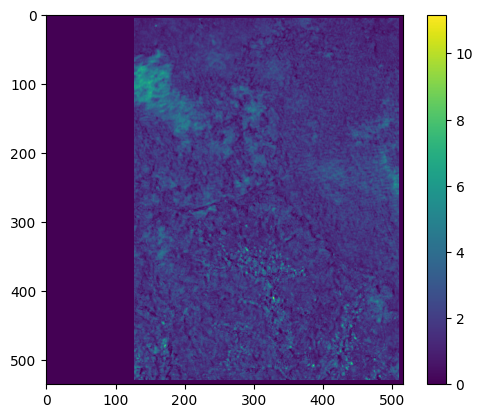

In [165]:
#results_ = results.copy()
#results_[results] == --9999. ]= 0
plt.imshow(results, vmin=0)#, vmax=10)
plt.colorbar()